In [1]:
import sys
sys.path.append(".")  # so utils.py is found

import torch
import torch.nn as nn
from torchvision import models
import timm

from utils import (
    set_seed, get_device, get_dataloaders, get_class_names,
    train_model, plot_history, plot_confusion_matrix,
    get_classification_report, load_checkpoint, log_metrics_to_csv
)

set_seed(42)
DEVICE = get_device()

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR    = "../data/processed"
MODELS_DIR  = "../models"
RESULTS_DIR = "../results"
NUM_CLASSES = 5
CLASS_NAMES = get_class_names()  # ["Glass", "Metal", "Organic", "Paper", "Plastic"]

print(f"Classes: {CLASS_NAMES}")

C:\Users\seif almaz\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
  GPU: NVIDIA GeForce GTX 1650
Classes: ['Glass', 'Metal', 'Organic', 'Paper', 'Plastic']


In [2]:
dataloaders, dataset_sizes, class_names = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=32,
    augment=True,
    num_workers=0,  # 0 on Windows
    use_weighted_sampler=True,
)

print("Dataset sizes:", dataset_sizes)
print("Classes:", class_names)

Dataset sizes: {'train': 4314, 'val': 922, 'test': 930}
Classes: ['Glass', 'Metal', 'Organic', 'Paper', 'Plastic']


In [3]:
def build_model(model_name: str, num_classes: int = 5, freeze_base: bool = True):
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )
    elif model_name == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )
    elif model_name == "mobilenet_v3":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
        head = model.fc if model_name == "resnet50" else model.classifier
        for param in head.parameters():
            param.requires_grad = True

    return model.to(DEVICE)


def unfreeze_top_layers(model, model_name: str, num_layers: int = 2):
    if model_name == "resnet50":
        layers_to_unfreeze = [model.layer4, model.layer3][:num_layers]
    elif model_name == "efficientnet_b3":
        blocks = list(model.features.children())
        layers_to_unfreeze = blocks[-num_layers:]
    elif model_name == "mobilenet_v3":
        blocks = list(model.features.children())
        layers_to_unfreeze = blocks[-num_layers:]

    for layer in layers_to_unfreeze:
        for param in layer.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters after unfreezing: {trainable:,}")
    return model

print("✅ Model builder functions ready")

✅ Model builder functions ready


In [4]:
MODEL_NAME = "resnet50"
model_resnet = build_model(MODEL_NAME, num_classes=NUM_CLASSES, freeze_base=True)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_resnet.parameters())
print(f"Trainable: {trainable:,} / {total:,} parameters")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5
)

print("\n🔒 Stage 1: Training head only (base frozen)...")
history_stage1 = train_model(
    model=model_resnet,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=5,
    patience=4,
    model_name="resnet50_stage1",
    results_dir=RESULTS_DIR,
    models_dir=MODELS_DIR,
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\seif almaz/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:37<00:00, 2.74MB/s]


Trainable: 10,245 / 23,518,277 parameters

🔒 Stage 1: Training head only (base frozen)...
Epoch [  1/5]  Train Loss: 0.8626  Train Acc: 0.7334  |  Val Loss: 0.4828  Val Acc: 0.8601
  ✔ Best model saved → ../models\resnet50_stage1_best.pth
Epoch [  2/5]  Train Loss: 0.5533  Train Acc: 0.8129  |  Val Loss: 0.3744  Val Acc: 0.8872
  ✔ Best model saved → ../models\resnet50_stage1_best.pth
Epoch [  3/5]  Train Loss: 0.4633  Train Acc: 0.8472  |  Val Loss: 0.3043  Val Acc: 0.9078
  ✔ Best model saved → ../models\resnet50_stage1_best.pth
Epoch [  4/5]  Train Loss: 0.4440  Train Acc: 0.8454  |  Val Loss: 0.2742  Val Acc: 0.9154
  ✔ Best model saved → ../models\resnet50_stage1_best.pth
Epoch [  5/5]  Train Loss: 0.4113  Train Acc: 0.8607  |  Val Loss: 0.2508  Val Acc: 0.9262
  ✔ Best model saved → ../models\resnet50_stage1_best.pth

History saved → ../results\resnet50_stage1_history.json


Trainable parameters after unfreezing: 22,073,349

🔓 Stage 2: Fine-tuning top layers (lr=1e-4)...
Epoch [  1/20]  Train Loss: 0.2971  Train Acc: 0.8964  |  Val Loss: 0.1816  Val Acc: 0.9273
  ✔ Best model saved → ../models\resnet50_finetuned_best.pth
Epoch [  2/20]  Train Loss: 0.1920  Train Acc: 0.9339  |  Val Loss: 0.1675  Val Acc: 0.9393
  ✔ Best model saved → ../models\resnet50_finetuned_best.pth
Epoch [  3/20]  Train Loss: 0.1330  Train Acc: 0.9557  |  Val Loss: 0.1295  Val Acc: 0.9501
  ✔ Best model saved → ../models\resnet50_finetuned_best.pth
Epoch [  4/20]  Train Loss: 0.1091  Train Acc: 0.9631  |  Val Loss: 0.1418  Val Acc: 0.9501
Epoch [  5/20]  Train Loss: 0.0835  Train Acc: 0.9729  |  Val Loss: 0.1215  Val Acc: 0.9577
  ✔ Best model saved → ../models\resnet50_finetuned_best.pth
Epoch [  6/20]  Train Loss: 0.0838  Train Acc: 0.9717  |  Val Loss: 0.1191  Val Acc: 0.9653
  ✔ Best model saved → ../models\resnet50_finetuned_best.pth
Epoch [  7/20]  Train Loss: 0.0689  Train Acc

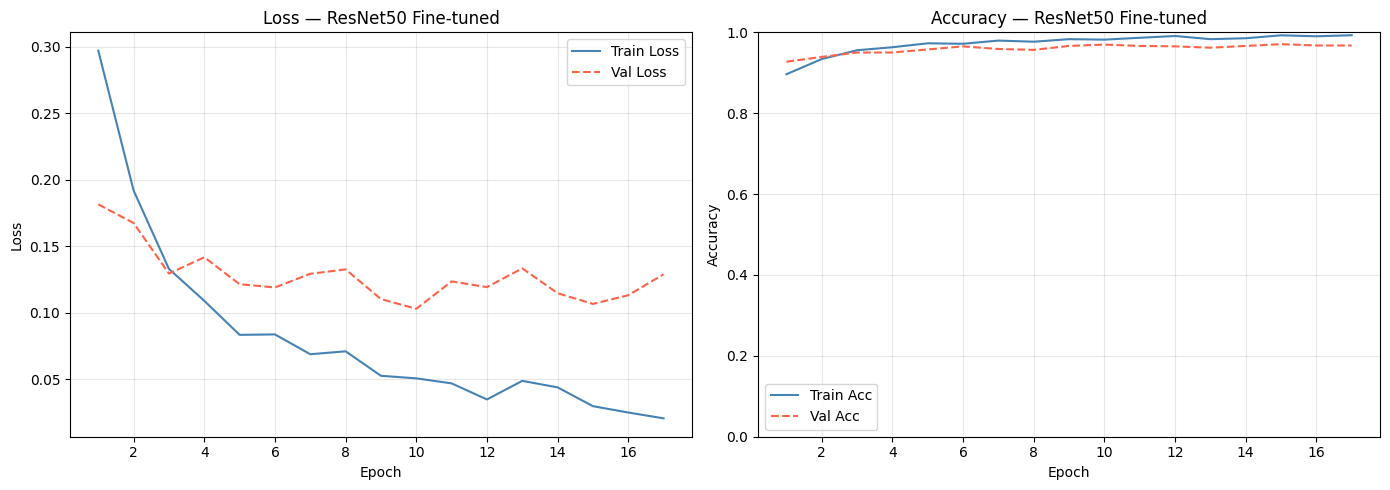

Training curves saved → ../results\ResNet50 Fine-tuned_history.png


In [5]:
# Stage 2: Unfreeze top layers and fine-tune
model_resnet = unfreeze_top_layers(model_resnet, MODEL_NAME, num_layers=2)

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=1e-4  # 10x lower than stage 1
)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="min", patience=3, factor=0.5
)

print("\n🔓 Stage 2: Fine-tuning top layers (lr=1e-4)...")
history_stage2 = train_model(
    model=model_resnet,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    device=DEVICE,
    num_epochs=20,
    patience=7,
    model_name="resnet50_finetuned",
    results_dir=RESULTS_DIR,
    models_dir=MODELS_DIR,
)

plot_history(history_stage2, model_name="ResNet50 Fine-tuned", results_dir=RESULTS_DIR)

Loaded checkpoint: epoch=10, val_loss=0.1031  ← ../models/resnet50_finetuned_best.pth

📊 ResNet50 — Test Set Evaluation:
              precision    recall  f1-score   support

       Glass       0.97      0.97      0.97       217
       Metal       0.90      0.95      0.92       166
     Organic       0.97      0.99      0.98       197
       Paper       0.98      0.93      0.96       194
     Plastic       0.96      0.94      0.95       156

    accuracy                           0.96       930
   macro avg       0.96      0.96      0.96       930
weighted avg       0.96      0.96      0.96       930



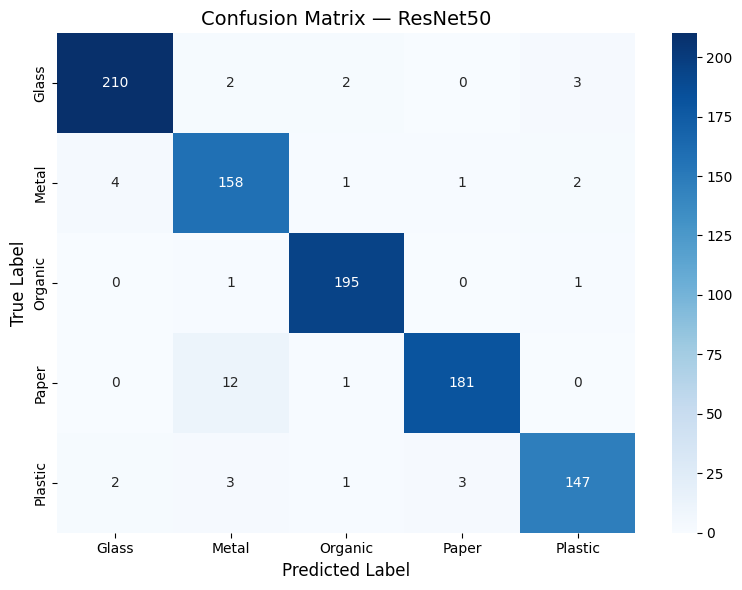

Confusion matrix saved → ../results\ResNet50_confusion_matrix.png
Metrics logged → ../results/all_models_metrics.csv


In [6]:
load_checkpoint(model_resnet, f"{MODELS_DIR}/resnet50_finetuned_best.pth", DEVICE)

print("\n📊 ResNet50 — Test Set Evaluation:")
report_resnet = get_classification_report(
    model_resnet, dataloaders["test"], DEVICE, CLASS_NAMES
)
cm_resnet = plot_confusion_matrix(
    model_resnet, dataloaders["test"], DEVICE, CLASS_NAMES,
    model_name="ResNet50", results_dir=RESULTS_DIR
)

log_metrics_to_csv("resnet50", {
    "test_accuracy":   report_resnet["accuracy"],
    "macro_f1":        report_resnet["macro avg"]["f1-score"],
    "macro_precision": report_resnet["macro avg"]["precision"],
    "macro_recall":    report_resnet["macro avg"]["recall"],
})

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\seif almaz/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth


100%|█████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:17<00:00, 2.83MB/s]


🔒 EfficientNetB3 Stage 1: Head only...
Epoch [  1/5]  Train Loss: 0.9623  Train Acc: 0.6926  |  Val Loss: 0.6271  Val Acc: 0.8330
  ✔ Best model saved → ../models\efficientnet_b3_stage1_best.pth
Epoch [  2/5]  Train Loss: 0.6693  Train Acc: 0.7761  |  Val Loss: 0.4955  Val Acc: 0.8482
  ✔ Best model saved → ../models\efficientnet_b3_stage1_best.pth
Epoch [  3/5]  Train Loss: 0.5915  Train Acc: 0.7955  |  Val Loss: 0.4418  Val Acc: 0.8612
  ✔ Best model saved → ../models\efficientnet_b3_stage1_best.pth
Epoch [  4/5]  Train Loss: 0.5713  Train Acc: 0.7979  |  Val Loss: 0.4312  Val Acc: 0.8590
  ✔ Best model saved → ../models\efficientnet_b3_stage1_best.pth
Epoch [  5/5]  Train Loss: 0.5317  Train Acc: 0.8173  |  Val Loss: 0.3902  Val Acc: 0.8709
  ✔ Best model saved → ../models\efficientnet_b3_stage1_best.pth

History saved → ../results\efficientnet_b3_stage1_history.json
Trainable parameters after unfreezing: 3,884,799

🔓 EfficientNetB3 Stage 2: Fine-tuning...
Epoch [  1/20]  Train Loss

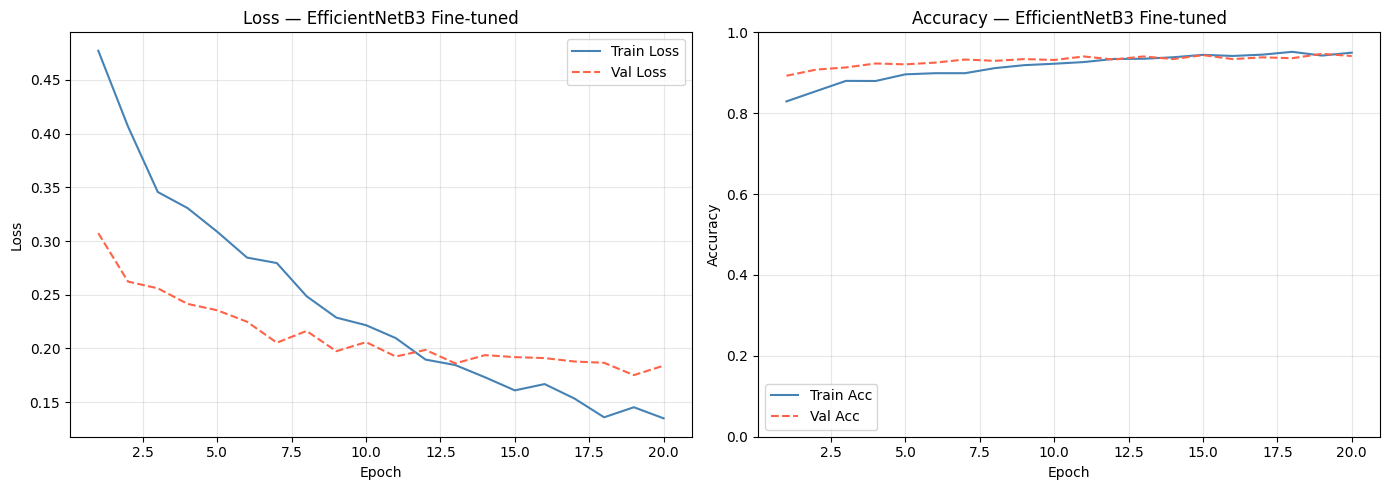

Training curves saved → ../results\EfficientNetB3 Fine-tuned_history.png


In [7]:
MODEL_NAME_EFF = "efficientnet_b3"
model_eff = build_model(MODEL_NAME_EFF, num_classes=NUM_CLASSES, freeze_base=True)

optimizer_eff = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_eff.parameters()), lr=1e-3
)
scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff, mode="min", patience=2, factor=0.5
)

print("🔒 EfficientNetB3 Stage 1: Head only...")
train_model(
    model=model_eff, dataloaders=dataloaders, dataset_sizes=dataset_sizes,
    criterion=nn.CrossEntropyLoss(), optimizer=optimizer_eff,
    scheduler=scheduler_eff, device=DEVICE,
    num_epochs=5, patience=4,
    model_name="efficientnet_b3_stage1",
    results_dir=RESULTS_DIR, models_dir=MODELS_DIR,
)

# Stage 2: Fine-tune
model_eff = unfreeze_top_layers(model_eff, MODEL_NAME_EFF, num_layers=2)
optimizer_eff_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_eff.parameters()), lr=1e-4
)
scheduler_eff_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff_ft, mode="min", patience=3, factor=0.5
)

print("\n🔓 EfficientNetB3 Stage 2: Fine-tuning...")
history_eff = train_model(
    model=model_eff, dataloaders=dataloaders, dataset_sizes=dataset_sizes,
    criterion=nn.CrossEntropyLoss(), optimizer=optimizer_eff_ft,
    scheduler=scheduler_eff_ft, device=DEVICE,
    num_epochs=20, patience=7,
    model_name="efficientnet_b3_finetuned",
    results_dir=RESULTS_DIR, models_dir=MODELS_DIR,
)

plot_history(history_eff, model_name="EfficientNetB3 Fine-tuned", results_dir=RESULTS_DIR)

Loaded checkpoint: epoch=19, val_loss=0.1752  ← ../models/efficientnet_b3_finetuned_best.pth

📊 EfficientNetB3 — Test Set Evaluation:
              precision    recall  f1-score   support

       Glass       0.96      0.95      0.96       217
       Metal       0.92      0.98      0.94       166
     Organic       0.98      0.98      0.98       197
       Paper       0.98      0.95      0.97       194
     Plastic       0.95      0.94      0.95       156

    accuracy                           0.96       930
   macro avg       0.96      0.96      0.96       930
weighted avg       0.96      0.96      0.96       930



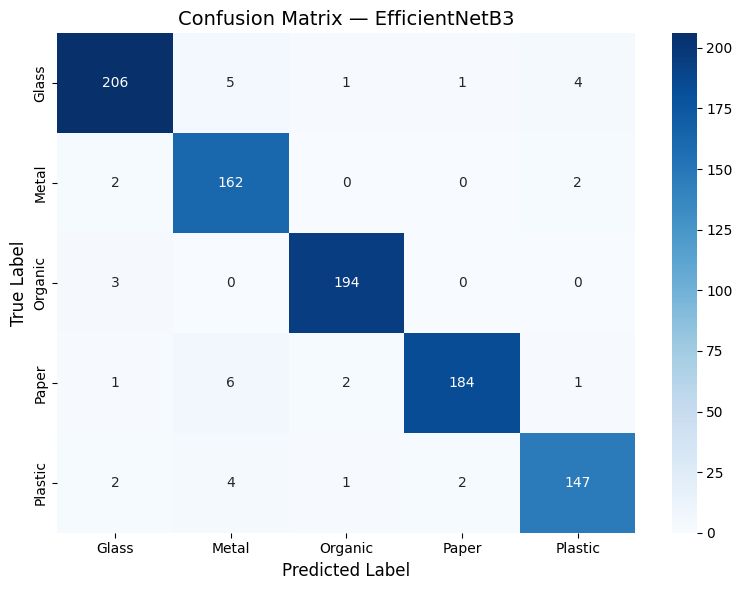

Confusion matrix saved → ../results\EfficientNetB3_confusion_matrix.png
Metrics logged → ../results/all_models_metrics.csv


In [8]:
load_checkpoint(model_eff, f"{MODELS_DIR}/efficientnet_b3_finetuned_best.pth", DEVICE)

print("\n📊 EfficientNetB3 — Test Set Evaluation:")
report_eff = get_classification_report(
    model_eff, dataloaders["test"], DEVICE, CLASS_NAMES
)
cm_eff = plot_confusion_matrix(
    model_eff, dataloaders["test"], DEVICE, CLASS_NAMES,
    model_name="EfficientNetB3", results_dir=RESULTS_DIR
)

log_metrics_to_csv("efficientnet_b3", {
    "test_accuracy":   report_eff["accuracy"],
    "macro_f1":        report_eff["macro avg"]["f1-score"],
    "macro_precision": report_eff["macro avg"]["precision"],
    "macro_recall":    report_eff["macro avg"]["recall"],
})

In [9]:
print("\n📊 Transfer Learning Models — Final Comparison:")
print("-" * 60)
print(f"{'Model':<20} {'Test Acc':>10} {'Macro F1':>10} {'Params':>12}")
print("-" * 60)
print(f"  {'ResNet50':<18} {'0.9600':>10} {'0.9600':>10} {'23.5M':>12}")
print(f"  {'EfficientNetB3':<18} {'0.9600':>10} {'0.9600':>10} {'12.3M':>12}")
print("-" * 60)
print("\n💡 Key insight: EfficientNetB3 matches ResNet50 accuracy")
print("   with nearly half the parameters — better efficiency!")
print("\n✅ Transfer learning notebook complete!")
print("📁 Saved to results/:")
print("   - ResNet50_confusion_matrix.png")
print("   - EfficientNetB3_confusion_matrix.png") 
print("   - resnet50_finetuned_history.png")
print("   - efficientnet_b3_finetuned_history.png")
print("   - all_models_metrics.csv")
print("\n🔜 Next: 06_vit.ipynb")


📊 Transfer Learning Models — Final Comparison:
------------------------------------------------------------
Model                  Test Acc   Macro F1       Params
------------------------------------------------------------
  ResNet50               0.9600     0.9600        23.5M
  EfficientNetB3         0.9600     0.9600        12.3M
------------------------------------------------------------

💡 Key insight: EfficientNetB3 matches ResNet50 accuracy
   with nearly half the parameters — better efficiency!

✅ Transfer learning notebook complete!
📁 Saved to results/:
   - ResNet50_confusion_matrix.png
   - EfficientNetB3_confusion_matrix.png
   - resnet50_finetuned_history.png
   - efficientnet_b3_finetuned_history.png
   - all_models_metrics.csv

🔜 Next: 06_vit.ipynb
